In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (9, 4.5)

# Carregamento da amostra
df = pd.read_parquet('base_analitica_amostra.parquet')
TARGET = 'alfabetizado'

# Proporção do alvo e dados gerais
print(f"Total de registros: {df.shape[0]:,} | Total de colunas: {df.shape[1]}")
prop_alvo = df[TARGET].value_counts(normalize=True) * 100
print(f"Alunos Alfabetizados (alvo = 1): {prop_alvo[1]:.1f}%")
print(f"Alunos Não Alfabetizados (alvo = 0): {prop_alvo[0]:.1f}%")

Total de registros: 296,292 | Total de colunas: 26
Alunos Alfabetizados (alvo = 1): 59.8%
Alunos Não Alfabetizados (alvo = 0): 40.2%


In [2]:
# 2. Auditoria de Possível Vazamento (Data Leakage) — antes de remover qualquer coluna

# Checagem: nivel_alfabetizacao é uma nota disfarçada de 2024?
print('Distribuição do alvo por nível de alfabetização:')
cruzamento_nivel = pd.crosstab(
    df['nivel_alfabetizacao'], df[TARGET], normalize='index'
) * 100
print(cruzamento_nivel.round(1))

# Caso haja vazamento (ou incerteza sobre ser de 2024), descartamos para segurança do modelo:
colunas_descarte = ['meta_alfabetizacao_2030']  # valor único (80)
if 'nivel_alfabetizacao' in df.columns:
    colunas_descarte.append('nivel_alfabetizacao')

df = df.drop(columns=colunas_descarte, errors='ignore')
print(f'\nColunas removidas por segurança/constância: {colunas_descarte}')

Distribuição do alvo por nível de alfabetização:
alfabetizado            0     1
nivel_alfabetizacao            
0                    65.2  34.8
1                    49.6  50.4
2                    44.6  55.4
3                    34.2  65.8
4                    25.3  74.7
5                    12.1  87.9

Colunas removidas por segurança/constância: ['meta_alfabetizacao_2030', 'nivel_alfabetizacao']


In [3]:
df

,id_aluno,id_escola,id_municipio,rede,caderno,peso_aluno,nome_municipio,sigla_uf,nome_regiao,nome_mesorregiao,...,va_agropecuaria,va_industria,va_servicos,va_adespss,taxa_municipio_2023,media_portugues_municipio_2023,meta_alfabetizacao_2024,meta_alfabetizacao_2026,percentual_participacao,alfabetizado
0,12009423,60000594,1200401,2,20,1.11,Rio Branco,AC,Norte,Vale do Acre,...,464933000,880534000,5153657000,2949436000,NaN,NaN,NaN,64.86,81.03,0
1,12008971,60000525,1200401,2,7,1.03,Rio Branco,AC,Norte,Vale do Acre,...,464933000,880534000,5153657000,2949436000,NaN,NaN,NaN,64.86,81.03,0
2,12003465,60000436,1200328,2,15,1.36,Jordão,AC,Norte,Vale do Juruá,...,21977000,2460000,14031000,73684000,NaN,NaN,NaN,38.39,93.88,0
3,12005920,60000409,1200609,2,17,1.40,Tarauacá,AC,Norte,Vale do Juruá,...,176339000,23416000,158432000,322737000,NaN,NaN,NaN,58.25,85.99,0
4,12005072,60000526,1200450,2,13,1.14,Senador Guiomard,AC,Norte,Vale do Acre,...,391220000,30582000,150418000,175830000,NaN,NaN,NaN,57.26,76.67,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
296287,17013519,60004243,1705508,3,10,1.17,Colinas do Tocantins,TO,Norte,Ocidental do Tocantins,...,92361000,78660000,333011000,261775000,51.01,737.8341,55.79,64.96,86.50,1
296288,17006119,60004247,1709500,4,2,1.04,Gurupi,TO,Norte,Ocidental do Tocantins,...,135884000,207473000,1239004000,707307000,44.44,734.5547,50.17,61.46,86.46,0
296289,17006123,60004247,1709500,4,6,1.04,Gurupi,TO,Norte,Ocidental do Tocantins,...,135884000,207473000,1239004000,707307000,44.44,734.5547,50.17,61.46,86.46,1
296290,17006132,60004247,1709500,4,1,1.04,Gurupi,TO,Norte,Ocidental do Tocantins,...,135884000,207473000,1239004000,707307000,44.44,734.5547,50.17,61.46,86.46,1


In [4]:
print(df.columns.tolist())

['id_aluno', 'id_escola', 'id_municipio', 'rede', 'caderno', 'peso_aluno', 'nome_municipio', 'sigla_uf', 'nome_regiao', 'nome_mesorregiao', 'capital_uf', 'amazonia_legal', 'populacao', 'pib', 'va_agropecuaria', 'va_industria', 'va_servicos', 'va_adespss', 'taxa_municipio_2023', 'media_portugues_municipio_2023', 'meta_alfabetizacao_2024', 'meta_alfabetizacao_2026', 'percentual_participacao', 'alfabetizado']


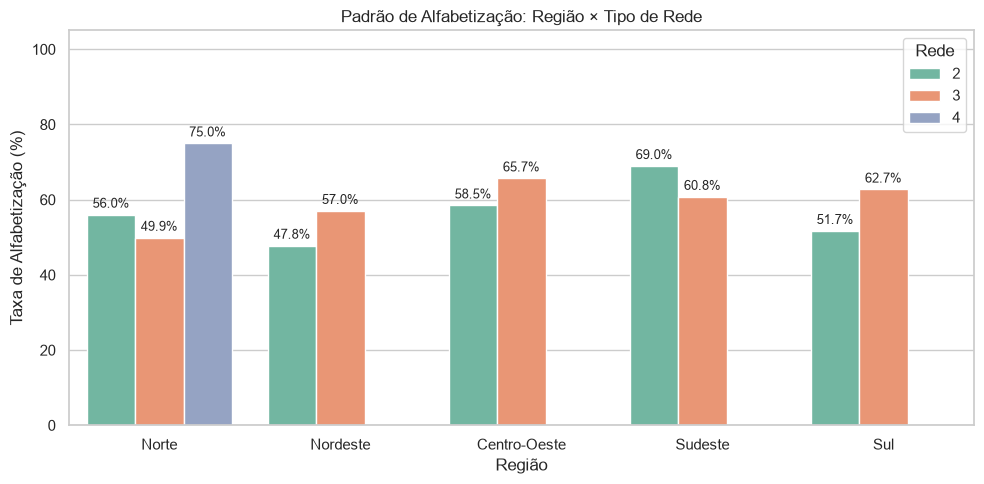

In [5]:
# Mapeamento do tipo de rede
mapa_rede = {
    'MUNICIPAL': 'Municipal', 'ESTADUAL': 'Estadual', 
    'FEDERAL': 'Federal', 'PRIVADA': 'Privada',
    'municipal': 'Municipal', 'estadual': 'Estadual',
    1: 'Federal', 2: 'Estadual', 3: 'Municipal', 4: 'Privada'
}
df['rede_nome'] = df['rede'].map(mapa_rede).fillna(df['rede'].astype(str).str.capitalize())

# Gráfico de padrão regional por rede
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=df, 
    x='nome_regiao', 
    y=TARGET, 
    hue='rede_nome', 
    estimator=lambda x: np.mean(x) * 100, 
    errorbar=None, 
    palette='Set2',
    ax=ax
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3, fontsize=9)

ax.set_title('Padrão de Alfabetização: Região × Tipo de Rede')
ax.set_xlabel('Região')
ax.set_ylabel('Taxa de Alfabetização (%)')
ax.set_ylim(0, 105)
ax.legend(title='Rede')
plt.tight_layout()
plt.show()

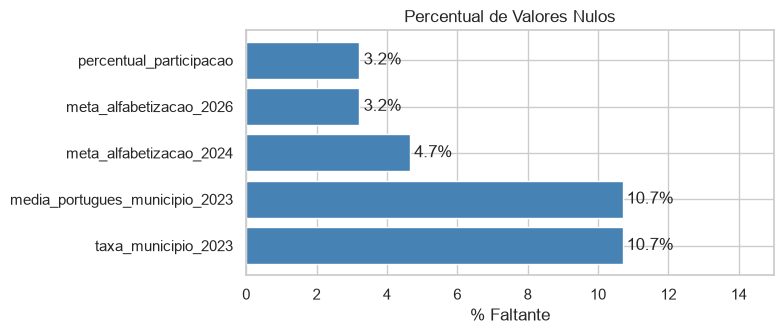

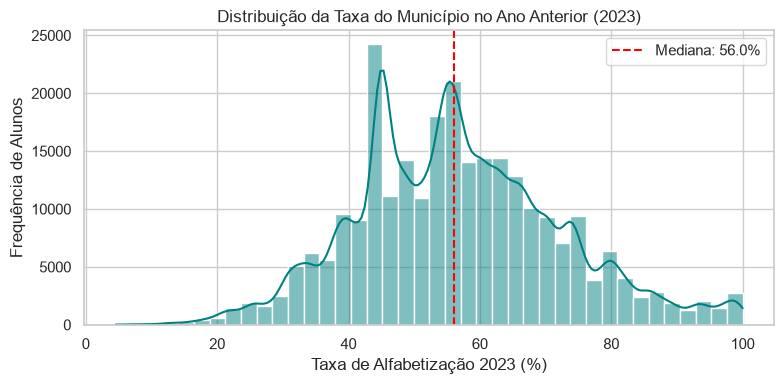

In [6]:
# A. Percentual de Nulos
nulos = (df.isnull().mean() * 100).loc[lambda x: x > 0].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 3.5))
bars = ax.barh(nulos.index, nulos.values, color='steelblue')
ax.bar_label(bars, fmt='%.1f%%', padding=3)
ax.set_xlim(0, 15)
ax.set_title('Percentual de Valores Nulos')
ax.set_xlabel('% Faltante')
plt.tight_layout()
plt.show()

# Criação da flag para os municípios que não realizaram a prova em 2023
df['sem_historico_2023'] = df['taxa_municipio_2023'].isnull().astype(int)

# B. Distribuição da nota histórica (2023)
plt.figure(figsize=(8, 4))
sns.histplot(df['taxa_municipio_2023'].dropna(), bins=40, kde=True, color='teal')
plt.axvline(df['taxa_municipio_2023'].median(), color='red', linestyle='--', 
            label=f"Mediana: {df['taxa_municipio_2023'].median():.1f}%")
plt.title('Distribuição da Taxa do Município no Ano Anterior (2023)')
plt.xlabel('Taxa de Alfabetização 2023 (%)')
plt.ylabel('Frequência de Alunos')
plt.legend()
plt.tight_layout()
plt.show()

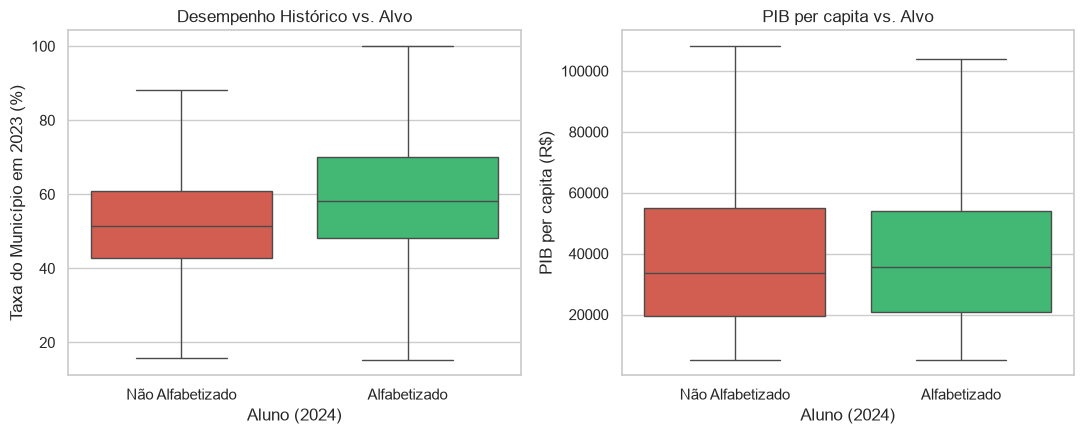

In [7]:
# Criação de variáveis per capita e proporção de despesa pública
df['pib_per_capita'] = df['pib'] / df['populacao'].replace(0, np.nan)
df['prop_adespss']   = df['va_adespss'] / df['pib'].replace(0, np.nan)

# Comparação do status do aluno com o histórico do município e renda per capita
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Boxplot Histórico 2023 vs Target
sns.boxplot(
    data=df, 
    x=TARGET, 
    y='taxa_municipio_2023', 
    palette=['#e74c3c', '#2ecc71'], 
    showfliers=False, 
    ax=axes[0]
)
axes[0].set_xticklabels(['Não Alfabetizado', 'Alfabetizado'])
axes[0].set_title('Desempenho Histórico vs. Alvo')
axes[0].set_xlabel('Aluno (2024)')
axes[0].set_ylabel('Taxa do Município em 2023 (%)')

# Boxplot Renda per capita vs Target
sns.boxplot(
    data=df, 
    x=TARGET, 
    y='pib_per_capita', 
    palette=['#e74c3c', '#2ecc71'], 
    showfliers=False, 
    ax=axes[1]
)
axes[1].set_xticklabels(['Não Alfabetizado', 'Alfabetizado'])
axes[1].set_title('PIB per capita vs. Alvo')
axes[1].set_xlabel('Aluno (2024)')
axes[1].set_ylabel('PIB per capita (R$)')

plt.tight_layout()
plt.show()

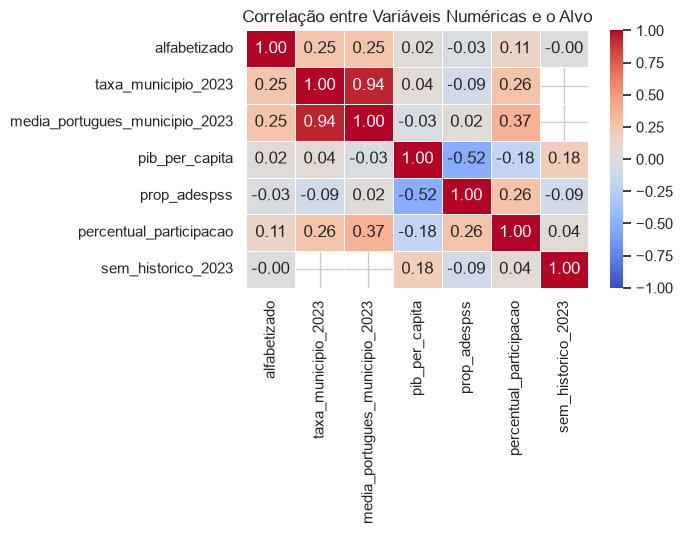

In [8]:
# Matriz de correlação linear das variáveis numéricas contínuas com o alvo
cols_corr = [
    TARGET, 
    'taxa_municipio_2023', 
    'media_portugues_municipio_2023',
    'pib_per_capita', 
    'prop_adespss', 
    'percentual_participacao',
    'sem_historico_2023'
]

matriz_corr = df[cols_corr].corr().round(2)

plt.figure(figsize=(7, 5.5))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f', linewidths=0.5)
plt.title('Correlação entre Variáveis Numéricas e o Alvo')
plt.tight_layout()
plt.show()

# Conclusões e Hipóteses para Modelagem
Hipótese do Efeito Histórico: O desempenho histórico do município (taxa_municipio_2023 e media_portugues_municipio_2023) é o fator de maior correlação com a alfabetização do aluno individualmente em 2024.

Hipótese de Desigualdade Regional e Federativa: A disparidade observada entre as regiões e entre as redes (estadual vs. municipal) indica que nome_regiao, sigla_uf e rede são variáveis categóricas indispensáveis para calibrar a probabilidade do modelo.

Hipótese do Dado Faltante Estrutural: A ausência de histórico em 2023 não ocorre por acaso e está associada a certas unidades federativas que não participaram no ano anterior; portanto, o uso da flag sem_historico_2023 combinada à imputação da mediana preservará essa informação sem distorcer o modelo.

Estratégia de Validação: Devido à forte dependência das notas em relação ao município de origem, a validação cruzada deve utilizar StratifiedGroupKFold agrupando por id_municipio, impedindo que alunos da mesma cidade fiquem simultaneamente no treino e teste.

# Resumo Executivo da Análise Exploratória (EDA)

## 1. Visão Geral dos Dados
* **Grão da Base:** Aluno individual do 2º ano do Ensino Fundamental avaliado em 2024.
* **Variável Alvo (`alfabetizado`):** Binária, balanceada de forma razoável (~60% alfabetizados e ~40% não alfabetizados), dispensando técnicas agressivas de reamostragem.
  * **Prevenção de Data Leakage (Vazamento):** A variável `nivel_alfabetizacao` foi removida por se tratar de uma discretização direta da nota da própria prova de 2024.
  * **Papel das variáveis:** `peso_aluno` foi separado como peso amostral (`sample_weight`) para uso no treinamento do modelo, e não como preditor.

## 2. Principais Padrões Identificados
* **Desigualdade Regional:** Regiões Sul e Sudeste apresentam as maiores taxas médias de alfabetização, enquanto Norte e Nordeste concentram as maiores defasagens.
* **Disparidade entre Redes:** Em praticamente todas as regiões, a **Rede Estadual** apresenta desempenho médio superior à **Rede Municipal**, indicando que a dependência administrativa é um fator relevante de distinção.


## 3. Análise de Nulos e Variáveis Relevantes
* **Mecanismo de Dados Faltantes:** Os valores nulos mais expressivos concentram-se no histórico de 2023 (`taxa_municipio_2023` com ~10,7% de nulos).
  * A ausência não tem relação com o tamanho da cidade, mas sim com a não adesão de determinados estados à avaliação anterior (ex.: SP, AC e DF).
  * **Tratamento adotado:** Imputação pela mediana acompanhada da criação de uma flag binária (`sem_historico_2023`).
* **Engenharia de Variáveis:** O cálculo de `pib_per_capita` e da proporção de gastos com administração pública (`prop_adespss`) normalizou distorções de tamanho entre os municípios.
* **Fator de Maior Correlação:** O histórico de desempenho do município no ano anterior (`taxa_municipio_2023`) é o indicador individual com maior correlação e capacidade de separação do alvo em 2024.


## 4. Hipóteses e Diretrizes para a Modelagem
1. **Poder Preditivo do Histórico:** O desempenho passado da cidade serve como uma base sólida de probabilidade a priori para o aluno.
2. **Importância dos Fatores Territoriais:** As variáveis `nome_regiao`, `sigla_uf` e `rede` devem entrar como preditoras essenciais para capturar as desigualdades estruturais.
3. **Estratégia de Validação:** Devido à correlação intra-município, a validação cruzada do modelo deve ser feita obrigatoriamente com **`StratifiedGroupKFold`** agrupado por `id_municipio`, garantindo que alunos de uma mesma cidade não fiquem simultaneamente no treino e no teste.
    